In [1]:
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np
from feature_selection.feature_selection_utils import iamb

# Simulate data
X_np, y_np = make_classification(
    n_samples=1000,
    n_features=100,
    n_informative=5,     # Only 5 features directly affect y
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    random_state=42,
    shuffle=True
)

# Create feature names
feature_names = [f"f{i}" for i in range(X_np.shape[1])]

# Discretize features (IAMB requires discrete data)
from sklearn.preprocessing import KBinsDiscretizer
disc = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
X_disc = disc.fit_transform(X_np)

# Create DataFrame
X_df = pd.DataFrame(X_disc, columns=feature_names)

# Run IAMB
mb = iamb(X_df, y_np, alpha=0.01, verbose=False)
print("Discovered Markov Blanket:", mb)


/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/work/SzollosiU/anzhelika-koldaeva/gene-context/ml

Discovered Markov Blanket: ['f14', 'f30', 'f0', 'f45', 'f82', 'f3', 'f48', 'f72']


In [16]:

# Run IAMB
mb = iamb(X_df, y_np, alpha=0.01, verbose=False)
print("Discovered Markov Blanket:", mb)

Discovered Markov Blanket: ['f14', 'f68', 'f0', 'f30', 'f13', 'f3']


In [17]:
true_mb = set(feature_names[:5])  # You know the first 5 are informative

print("True MB:", true_mb)
print("Recovered MB:", set(mb))
print("Intersection:", set(mb) & true_mb)
print(f"Recovered {len(set(mb) & true_mb)} of 5 true features")


True MB: {'f0', 'f2', 'f3', 'f4', 'f1'}
Recovered MB: {'f68', 'f14', 'f0', 'f30', 'f13', 'f3'}
Intersection: {'f0', 'f3'}
Recovered 2 of 5 true features


In [4]:
from collections import Counter

all_mbs = []
for i in range(10):
    X_np, y_np = make_classification(n_samples=1000, n_features=100,
                                     n_informative=5, n_redundant=0,
                                     random_state=i)
    X_disc = disc.fit_transform(X_np)
    X_df = pd.DataFrame(X_disc, columns=feature_names)
    mb = iamb(X_df, y_np, alpha=0.01, verbose=False)
    all_mbs.append(set(mb))

# Count how often each feature is selected
counts = Counter([f for mb in all_mbs for f in mb])
print("Feature selection frequencies:", counts)


/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib

Feature selection frequencies: Counter({'f18': 4, 'f28': 3, 'f68': 3, 'f76': 3, 'f27': 3, 'f7': 3, 'f31': 3, 'f24': 3, 'f78': 3, 'f46': 3, 'f72': 3, 'f49': 3, 'f26': 2, 'f12': 2, 'f47': 2, 'f57': 2, 'f63': 2, 'f23': 2, 'f92': 2, 'f55': 2, 'f62': 2, 'f52': 2, 'f74': 2, 'f48': 2, 'f8': 2, 'f16': 2, 'f43': 2, 'f9': 2, 'f60': 2, 'f64': 2, 'f1': 2, 'f11': 2, 'f69': 2, 'f80': 2, 'f65': 2, 'f25': 2, 'f96': 2, 'f13': 2, 'f89': 1, 'f79': 1, 'f84': 1, 'f70': 1, 'f54': 1, 'f71': 1, 'f51': 1, 'f40': 1, 'f50': 1, 'f56': 1, 'f85': 1, 'f77': 1, 'f5': 1, 'f58': 1, 'f93': 1, 'f98': 1, 'f33': 1, 'f83': 1, 'f42': 1, 'f34': 1, 'f29': 1, 'f94': 1, 'f99': 1, 'f87': 1, 'f39': 1, 'f61': 1, 'f30': 1, 'f73': 1, 'f32': 1, 'f95': 1, 'f67': 1, 'f10': 1, 'f0': 1, 'f53': 1, 'f15': 1, 'f19': 1, 'f22': 1, 'f82': 1})


In [20]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_disc, y_np, discrete_features=True)
mi_scores = list(zip(feature_names, mi))
mi_scores.sort(key=lambda x: -x[1])

print("Top 10 features by MI with target:")
for feat, score in mi_scores[:10]:
    print(f"{feat}: {score:.3f}")


Top 10 features by MI with target:
f14: 0.139
f0: 0.072
f3: 0.056
f30: 0.054
f4: 0.023
f52: 0.006
f45: 0.005
f98: 0.005
f78: 0.005
f87: 0.005


In [21]:
for a in [0.001, 0.01, 0.05, 0.1]:
    mb = iamb(X_df, y_np, alpha=a, verbose=False)
    print(f"alpha={a}: MB size={len(mb)}, MB = {mb}; recovered={set(mb) & true_mb}")


alpha=0.001: MB size=9, MB = ['f78', 'f48', 'f14', 'f0', 'f82', 'f30', 'f3', 'f72', 'f45']; recovered={'f0', 'f3'}
alpha=0.01: MB size=8, MB = ['f48', 'f14', 'f0', 'f82', 'f30', 'f3', 'f72', 'f45']; recovered={'f0', 'f3'}
alpha=0.05: MB size=4, MB = ['f0', 'f3', 'f30', 'f14']; recovered={'f0', 'f3'}
alpha=0.1: MB size=3, MB = ['f3', 'f30', 'f14']; recovered={'f3'}


In [1]:
import pandas as pd
import numpy as np
import torch
import os
import sys
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from utils.utils import read_aerob_data, pca_run_and_plot, tsne_plot

TAX_LEVEL = "random"  # <----------------- taxonomy level for train/test split is here!!
DATA_DIRECTORY = "data_aerob"  # <-------- input data directory is here!!
NUM_SPLITS_TO_READ = 30  # <-------------- number of splits to read and process is here!!

RANDOM_SEED = 42
OUTPUT_DIRECTORY = f"../{DATA_DIRECTORY}/outputs/{TAX_LEVEL}"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
from collections import defaultdict

all_splits_dict = defaultdict(int)
for split_id in range(NUM_SPLITS_TO_READ):
    # Read train data
    data_filename_train = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/train_data_{TAX_LEVEL}_tax_level_split_{split_id}"
    y_filename_train = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/train_annot_{TAX_LEVEL}_tax_level_split_{split_id}"
    taxa_names_filename_train = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/train_taxa_names_{TAX_LEVEL}_tax_level_split_{split_id}" if TAX_LEVEL != "random" else None
    X_val_train, y_label_train, X_column_names, taxa_group_names_train = read_aerob_data(data_filename_train, y_filename_train, taxa_names_filename_train, DEVICE)  
    
    # Read test data
    data_filename_test = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/test_data_{TAX_LEVEL}_tax_level_split_{split_id}"
    y_filename_test = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/test_annot_{TAX_LEVEL}_tax_level_split_{split_id}"
    taxa_names_filename_test = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/test_taxa_names_{TAX_LEVEL}_tax_level_split_{split_id}"  if TAX_LEVEL != "random" else None
    X_val_test, y_label_test, X_column_names, taxa_group_names_test = read_aerob_data(data_filename_test, y_filename_test, taxa_names_filename_test, DEVICE)  

    curr_split_dict = defaultdict(str)
    curr_split_dict["X_train"] = X_val_train
    curr_split_dict["y_train"] = y_label_train
    curr_split_dict["taxa_group_names_train"] = taxa_group_names_train
    curr_split_dict["X_test"] = X_val_test
    curr_split_dict["y_test"] = y_label_test
    curr_split_dict["taxa_group_names_test"] = taxa_group_names_test
    curr_split_dict["feature_names"] = X_column_names

    all_splits_dict[split_id] = curr_split_dict
    
print(f"Number of added splits = {len(all_splits_dict.keys())}")    

Number of added splits = 30


In [48]:
X_np = X_val_train.cpu().numpy()  
X_np = (X_np > 0).astype(int)


            # X_np = (X_np > 0).astype(int)
        
            # selected_columns = [f"{X_column_names[i]}" for i in range(X_np.shape[1])]
            # X_filtered = pd.DataFrame(X_np, columns=np.array(selected_columns))#[selector.get_support()])

y_np = y_label_train.cpu().numpy() 

# disc = KBinsDiscretizer(n_bins=2, encode='ordinal', strategy='uniform')
# X_disc = disc.fit_transform(X_np)

#selected_columns = [f"{X_column_names[i]}" for i in range(X_np.shape[1])]
#X_filtered = pd.DataFrame(X_disc, columns=np.array(selected_columns))#[selector.get_support()])

X_df = pd.DataFrame(X_np, columns=X_column_names)

In [49]:
X_np

array([[1, 1, 0, ..., 0, 0, 0],
       [1, 1, 0, ..., 0, 1, 0],
       [1, 1, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0]], shape=(2578, 2677))

In [50]:
X_df

,COG0001,COG0002,COG0003,COG0004,COG0005,COG0007,COG0008,COG0010,COG0012,COG0013,...,COG5611,COG5615,COG5621,COG5625,COG5632,COG5640,COG5643,COG5650,COG5652,COG5663
0,1,1,0,1,0,0,0,0,1,1,...,0,0,1,0,0,0,0,0,0,0
1,1,1,0,1,0,0,1,1,1,1,...,0,0,0,0,0,0,0,0,1,0
2,1,1,0,1,1,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,1,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2573,1,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
2574,0,0,0,0,0,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
2575,1,0,0,1,0,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2576,0,1,0,0,0,1,1,0,1,1,...,0,0,0,0,1,0,0,0,0,0


In [51]:
X_df.sample(axis=1, frac=1, replace=False)

,COG4239,COG3715,COG3010,COG1812,COG0322,COG3572,COG4544,COG4909,COG3623,COG0534,...,COG1876,COG3579,COG1138,COG2968,COG0462,COG0418,COG0114,COG0509,COG4116,COG4710
0,0,0,0,0,1,0,1,0,0,1,...,1,0,1,1,1,1,1,1,0,0
1,0,0,0,0,1,0,0,0,0,1,...,1,0,0,0,1,0,1,1,0,0
2,0,0,0,1,1,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,0
3,0,0,0,0,1,1,0,0,0,1,...,0,1,0,0,1,0,0,1,0,0
4,0,1,0,0,1,0,0,1,0,1,...,1,0,0,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2573,0,0,0,0,1,1,1,0,0,1,...,1,0,1,1,1,0,1,1,0,0
2574,0,0,1,0,1,0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
2575,0,0,0,0,1,0,1,0,0,1,...,0,1,1,0,1,0,1,1,0,0
2576,0,1,1,0,1,0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0


In [52]:
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

X_train_column_names = X_df.columns

contin_flag = False
if contin_flag == False:
    mutual_info = mutual_info_classif(X_val_train.cpu(), y_label_train.cpu(), random_state=42)
else:
    mutual_info = mutual_info_regression(X_val_train.cpu(), y_label_train.cpu(), random_state=42)

sorted_indices = np.argsort(mutual_info)[::-1] 
sorted_mi = [mutual_info[i] for i in sorted_indices]
sorted_names = [X_train_column_names[i] for i in sorted_indices]

In [53]:
X_train_np = np.array(X_val_train.cpu())
X_train_transposed = X_train_np.T

/scratch/ipykernel_1830462/860185482.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_train_np = np.array(X_val_train.cpu())


In [54]:
N = 15
top_N_indices = sorted_indices[:N]
top_N_mi = sorted_mi[:N]
top_N_names_by_mi = sorted_names[:N]
top_feat_mi_counts = [X_train_transposed[i] for i in sorted_indices[:N]]

print(f"Top {N} COGs:", top_N_names_by_mi)

Top 15 COGs: ['COG0109', 'COG1612', 'COG1592', 'COG0026', 'COG0276', 'COG0508', 'COG0843', 'COG0365', 'COG1328', 'COG0065', 'COG0320', 'COG0567', 'COG1014', 'COG4624', 'COG0543']


In [55]:
N = 1000
top_N_indices = sorted_indices[:N]
X_df = X_df.iloc[:, top_N_indices]
X_df.columns

Index(['COG0109', 'COG1612', 'COG1592', 'COG0026', 'COG0276', 'COG0508',
       'COG0843', 'COG0365', 'COG1328', 'COG0065',
       ...
       'COG3531', 'COG0345', 'COG2959', 'COG0411', 'COG1450', 'COG0510',
       'COG1199', 'COG3710', 'COG0798', 'COG2178'],
      dtype='object', length=1000)

In [56]:
from feature_selection.feature_selection_utils import iamb

mb_orig = iamb(X_df, y_np, alpha=0.01)
mb_orig

/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/work/SzollosiU/anzhelika-koldaeva/gene-context

['COG1328', 'COG0109', 'COG4445', 'COG1237', 'COG0026', 'COG0508', 'COG1014']

In [57]:
from collections import Counter

mb_list = []
for i in range(10):
    print(f"i = {i}")
    sample = X_df.sample(frac=1, replace=True)
   # sample = X_df.sample(axis=1, frac=1, replace=False)
    print(f"len = {len(sample.index)}; num uniq = {len(np.unique(sample.index))}")
    y_sample = y_np[sample.index]
    mb = iamb(sample, y_sample, alpha=0.01)
    print(mb[:])
    mb_list.append(frozenset(mb[:]))

counts = Counter(mb_list)
print("Most common MB:", counts.most_common(3))


i = 0
len = 2578; num uniq = 1634
['COG1592', 'COG2211', 'COG1328', 'COG2231', 'COG0109', 'COG1070', 'COG1090', 'COG0026', 'COG1350']
i = 1
len = 2578; num uniq = 1626


/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/work/SzollosiU/anzhelika-koldaeva/gene-context

['COG1328', 'COG2824', 'COG2984', 'COG0109', 'COG3104', 'COG1090', 'COG1064', 'COG0026', 'COG1014']
i = 2
len = 2578; num uniq = 1635
['COG1328', 'COG1049', 'COG0109', 'COG2115', 'COG0508', 'COG1014', 'COG0733']
i = 3
len = 2578; num uniq = 1635


/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/work/SzollosiU/anzhelika-koldaeva/gene-context

['COG1328', 'COG0109', 'COG2158', 'COG3201', 'COG1578', 'COG0508', 'COG1014', 'COG0659']
i = 4
len = 2578; num uniq = 1620
['COG1328', 'COG0109', 'COG4445', 'COG1350', 'COG0508', 'COG0208', 'COG1014']
i = 5
len = 2578; num uniq = 1646


...

['COG1328', 'COG0109', 'COG4445', 'COG2764', 'COG3201', 'COG0026', 'COG1014', 'COG0826']
i = 6
len = 2578; num uniq = 1626
['COG1108', 'COG1328', 'COG2231', 'COG0109', 'COG2158', 'COG3201', 'COG0026', 'COG1014', 'COG2352']
i = 7
len = 2578; num uniq = 1648


/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/work/SzollosiU/anzhelika-koldaeva/gene-context

['COG1049', 'COG2876', 'COG0109', 'COG1054', 'COG0476', 'COG1764', 'COG1014']
i = 8
len = 2578; num uniq = 1619


/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/work/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/work/SzollosiU/anzhelika-koldaeva/gene-context

['COG1328', 'COG2231', 'COG0109', 'COG3201', 'COG0213', 'COG0259', 'COG1252', 'COG1014', 'COG2352']
i = 9
len = 2578; num uniq = 1626
['COG1328', 'COG2231', 'COG0109', 'COG2158', 'COG0026', 'COG0508', 'COG0167', 'COG1014', 'COG2352']
Most common MB: [(frozenset({'COG1592', 'COG2211', 'COG1328', 'COG2231', 'COG0109', 'COG1070', 'COG1090', 'COG0026', 'COG1350'}), 1), (frozenset({'COG2984', 'COG1328', 'COG2824', 'COG0109', 'COG3104', 'COG1090', 'COG1064', 'COG0026', 'COG1014'}), 1), (frozenset({'COG1049', 'COG1328', 'COG0109', 'COG2115', 'COG0508', 'COG1014', 'COG0733'}), 1)]


In [59]:
mb_list

[frozenset({'COG0026',
            'COG0109',
            'COG1070',
            'COG1090',
            'COG1328',
            'COG1350',
            'COG1592',
            'COG2211',
            'COG2231'}),
 frozenset({'COG0026',
            'COG0109',
            'COG1014',
            'COG1064',
            'COG1090',
            'COG1328',
            'COG2824',
            'COG2984',
            'COG3104'}),
 frozenset({'COG0109',
            'COG0508',
            'COG0733',
            'COG1014',
            'COG1049',
            'COG1328',
            'COG2115'}),
 frozenset({'COG0109',
            'COG0508',
            'COG0659',
            'COG1014',
            'COG1328',
            'COG1578',
            'COG2158',
            'COG3201'}),
 frozenset({'COG0109',
            'COG0208',
            'COG0508',
            'COG1014',
            'COG1328',
            'COG1350',
            'COG4445'}),
 frozenset({'COG0026',
            'COG0109',
            'COG0826',
 

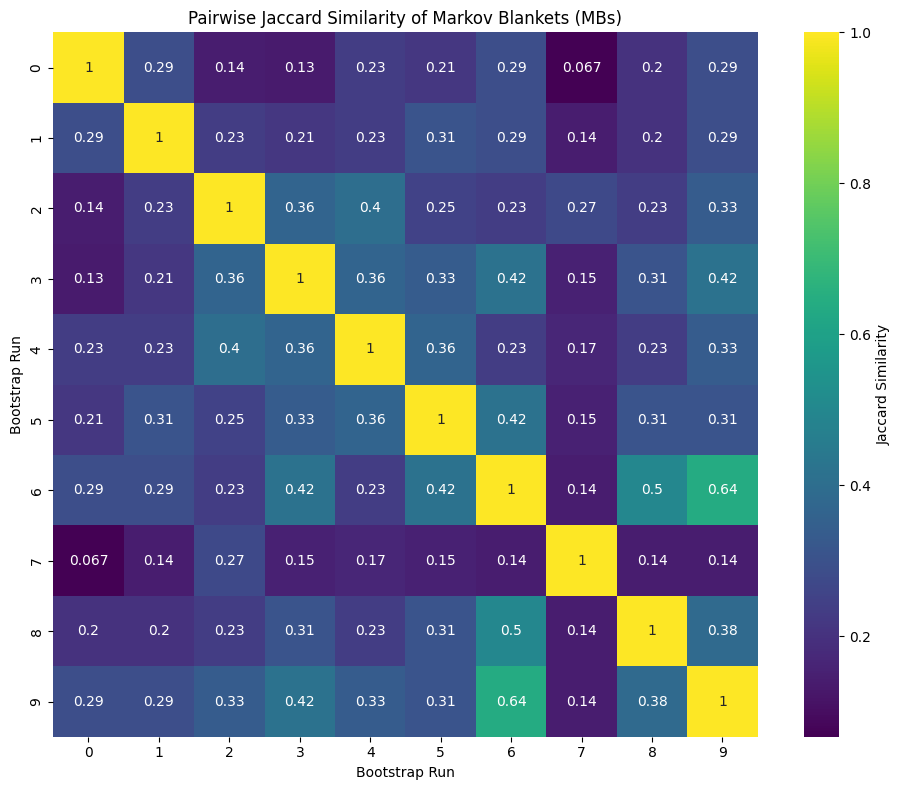

In [60]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

# Suppose mb_list contains frozensets of MBs from bootstrapping
n = len(mb_list)
jaccard_matrix = np.zeros((n, n))
jacc_indic = []
# Compute pairwise Jaccard similarities
for i in range(n):
    for j in range(n):
        if i == j:
            jaccard_matrix[i, j] = 1.0
        else:
            a, b = mb_list[i], mb_list[j]
            intersection = len(a & b)
            union = len(a | b)
            jaccard_matrix[i, j] = intersection / union if union > 0 else 0
            if i > j:
                jacc_indic.append(jaccard_matrix[i, j])

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(jaccard_matrix, annot=True, cmap="viridis", square=True, cbar_kws={'label': 'Jaccard Similarity'})
plt.title("Pairwise Jaccard Similarity of Markov Blankets (MBs)")
plt.xlabel("Bootstrap Run")
plt.ylabel("Bootstrap Run")
plt.tight_layout()
plt.show()


0.35686091686091687
8.2


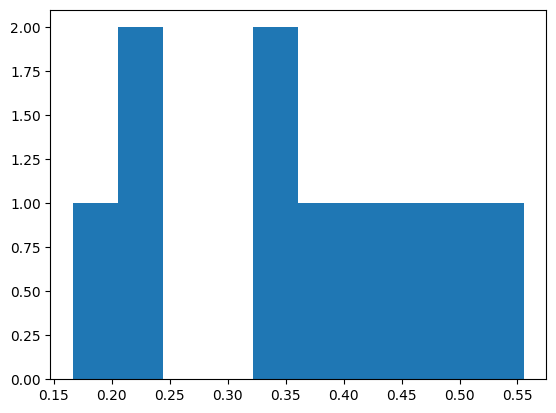

In [61]:

len(mb_list)
jacc_id_list = []
length_lst = []
for mb in mb_list:
    intersection = len(mb & set(mb_orig))
    length_lst.append(len(mb))
    union = len(mb | set(mb_orig))
    jacc_id_list.append(intersection / union if union > 0 else 0)

plt.hist(jacc_id_list);
print(np.mean(jacc_id_list))
print(np.mean(length_lst))

In [56]:
np.mean(jacc_indic)

np.float64(0.15900320812085517)

In [57]:
np.std(jacc_indic)

np.float64(0.08591492480362678)

In [58]:
a = frozenset({'COG0026',
            'COG0109',
            'COG1014',
            'COG1328',
            'COG1346',
            'COG1350',
            'COG1814',
            'COG1970',
            'COG4445',
            'COG4973'})
b = frozenset({'COG0026',
            'COG0109',
            'COG0241',
            'COG1014',
            'COG1592',
            'COG1989',
            'COG2231',
            'COG3022'})

In [59]:
intersection = len(a & b)
union = len(a | b)
jaccard_matrix[i, j] = intersection / union if union > 0 else 0

In [60]:
intersection / union if union > 0 else 0

0.2

In [65]:
mb

['COG3604',
 'COG3386',
 'COG1014',
 'COG4445',
 'COG1578',
 'COG0208',
 'COG0109',
 'COG2076']

In [64]:
import networkx as nx

In [70]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def draw_markov_blanket_full(X_df, y_sample, mb, target_name='Phenotype', connect_features=True, method='correlation', threshold=0.3):
    """
    Visualize Markov Blanket as a graph with optional edges between MB features.

    Parameters:
    - X_df: DataFrame with original features
    - y_sample: Target phenotype (not used here except for naming)
    - mb: List of selected MB feature names
    - target_name: Label of the target node
    - connect_features: Whether to add edges between MB features
    - method: 'correlation' or 'mutual_info' to compute edge weights
    - threshold: Minimum weight to draw an edge between MB features
    """
    G = nx.Graph()
    G.add_node(target_name, color='salmon')

    # Add nodes and edges to target
    for feat in mb:
        if feat in X_df.columns:
            G.add_node(feat, color='lightblue')
            G.add_edge(feat, target_name)

    # Optionally connect MB features based on pairwise relationships
    if connect_features:
        X_mb = X_df[mb]

        if method == 'correlation':
            corr = X_mb.corr().abs()
            for i in range(len(mb)):
                for j in range(i+1, len(mb)):
                    f1, f2 = mb[i], mb[j]
                    weight = corr.loc[f1, f2]
                    if weight >= threshold:
                        G.add_edge(f1, f2, weight=weight)

        elif method == 'mutual_info':
            from sklearn.metrics import mutual_info_score
            for i in range(len(mb)):
                for j in range(i+1, len(mb)):
                    f1, f2 = mb[i], mb[j]
                    mi = mutual_info_score(X_mb[f1], X_mb[f2])
                    if mi >= threshold:
                        G.add_edge(f1, f2, weight=mi)

    # Draw graph
    node_colors = [G.nodes[n]['color'] for n in G.nodes()]
    pos = nx.spring_layout(G, seed=42)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw(G, pos, with_labels=True, node_color=node_colors,
            node_size=1200, font_size=9, edge_color='gray')
    
    # Optional: show edge weights
    if edge_labels:
        edge_labels = {k: f"{v:.2f}" for k, v in edge_labels.items()}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Markov Blanket Graph with Feature Connections")
    plt.show()


In [84]:
mb_list


[frozenset({'COG0026',
            'COG0109',
            'COG0692',
            'COG1108',
            'COG1328',
            'COG1814',
            'COG2145',
            'COG2350',
            'COG3185',
            'COG4231'}),
 frozenset({'COG0109',
            'COG0649',
            'COG1090',
            'COG1350',
            'COG1592',
            'COG1981',
            'COG3387',
            'COG4231'}),
 frozenset({'COG0026',
            'COG0109',
            'COG1091',
            'COG1592',
            'COG1764',
            'COG2352',
            'COG3001',
            'COG3185',
            'COG3201',
            'COG4477'}),
 frozenset({'COG0026',
            'COG0109',
            'COG0283',
            'COG1014',
            'COG1022',
            'COG1090',
            'COG2984',
            'COG3185',
            'COG3830'}),
 frozenset({'COG0109',
            'COG0252',
            'COG0506',
            'COG0508',
            'COG1014',
            'COG1592',
   

In [98]:
a =['COG0109','COG1014', 'COG0026', 'COG0508', 'COG2158']
list(mb_list[5])

['COG2902',
 'COG1866',
 'COG1014',
 'COG0026',
 'COG3470',
 'COG2717',
 'COG1090',
 'COG0109',
 'COG2231']

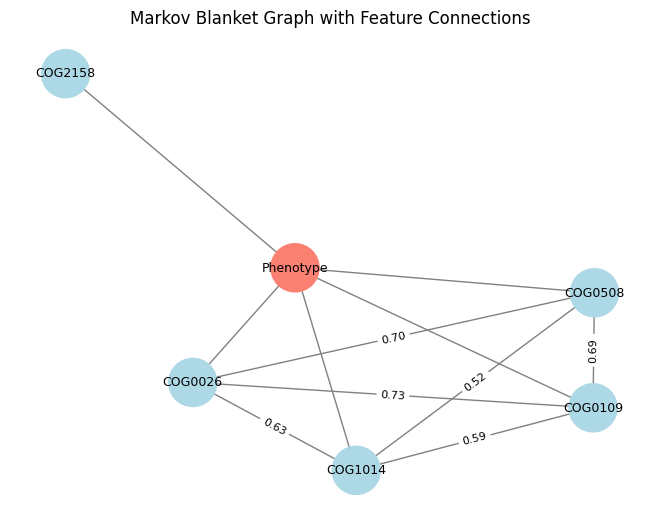

In [99]:
draw_markov_blanket_full(X_df, y_sample,a, target_name='Phenotype', connect_features=True, method='correlation', threshold=0.4)

In [97]:
import networkx as nx
import matplotlib.pyplot as plt
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
import pandas as pd

# Prepare data with Y + MB features
MB_list = ['COG0012', 'COG0345', 'COG0567', 'COG0789']  # replace with your MB features
data = pd.concat([pd.Series(y, name='Y'), X[MB_list]], axis=1)

# Run PC algorithm
cg = pc(data.values, alpha=0.01, indep_test_func=fisherz)

# cg.G is the learned graph structure
G_cg = cg.G

# Create NetworkX DiGraph
G_nx = nx.DiGraph()

# Add nodes with labels
nodes = data.columns.tolist()
G_nx.add_nodes_from(nodes)

# Add edges based on cg.G adjacency matrix and edge types
# causallearn Graph uses edges stored in G_cg.get_edges()
for edge in G_cg.get_edges():
    src = nodes[edge.node1]
    dst = nodes[edge.node2]

    # Edge types:
    # edge.type can be:
    # 1: directed edge node1 -> node2
    # 2: directed edge node2 -> node1
    # 3: undirected edge

    if edge.type == 1:
        G_nx.add_edge(src, dst)
    elif edge.type == 2:
        G_nx.add_edge(dst, src)
    elif edge.type == 3:
        # For undirected edges, add edges in both directions or use nx.Graph()
        G_nx.add_edge(src, dst)
        G_nx.add_edge(dst, src)

# Draw graph
pos = nx.spring_layout(G_nx, seed=42)
nx.draw(G_nx, pos, with_labels=True, node_size=2000, node_color='lightblue', arrows=True)
plt.title("Causal DAG from PC Algorithm")
plt.show()



ModuleNotFoundError: No module named 'causallearn'

In [ ]:
import pandas as pd
import numpy as np
import torch
import os
import sys
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from utils.utils import read_aerob_data, pca_run_and_plot, tsne_plot

TAX_LEVEL = "random"  # <----------------- taxonomy level for train/test split is here!!
DATA_DIRECTORY = "data_aerob"  # <-------- input data directory is here!!
NUM_SPLITS_TO_READ = 2  # <-------------- number of splits to read and process is here!!

RANDOM_SEED = 42
OUTPUT_DIRECTORY = f"../{DATA_DIRECTORY}/outputs/{TAX_LEVEL}"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from collections import defaultdict

all_splits_dict = defaultdict(int)
for split_id in range(NUM_SPLITS_TO_READ):
    # Read train data
    data_filename_train = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/train_data_{TAX_LEVEL}_tax_level_split_{split_id}"
    y_filename_train = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/train_annot_{TAX_LEVEL}_tax_level_split_{split_id}"
    taxa_names_filename_train = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/train_taxa_names_{TAX_LEVEL}_tax_level_split_{split_id}" if TAX_LEVEL != "random" else None
    X_val_train, y_label_train, X_column_names, taxa_group_names_train = read_aerob_data(data_filename_train, y_filename_train, taxa_names_filename_train, DEVICE)  
    
    # Read test data
    data_filename_test = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/test_data_{TAX_LEVEL}_tax_level_split_{split_id}"
    y_filename_test = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/test_annot_{TAX_LEVEL}_tax_level_split_{split_id}"
    taxa_names_filename_test = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/test_taxa_names_{TAX_LEVEL}_tax_level_split_{split_id}"  if TAX_LEVEL != "random" else None
    X_val_test, y_label_test, X_column_names, taxa_group_names_test = read_aerob_data(data_filename_test, y_filename_test, taxa_names_filename_test, DEVICE)  

    curr_split_dict = defaultdict(str)
    curr_split_dict["X_train"] = X_val_train
    curr_split_dict["y_train"] = y_label_train
    curr_split_dict["taxa_group_names_train"] = taxa_group_names_train
    curr_split_dict["X_test"] = X_val_test
    curr_split_dict["y_test"] = y_label_test
    curr_split_dict["taxa_group_names_test"] = taxa_group_names_test
    curr_split_dict["feature_names"] = X_column_names

    all_splits_dict[split_id] = curr_split_dict
    
print(f"Number of added splits = {len(all_splits_dict.keys())}")    

In [ ]:
X_np = X_val_train.cpu().numpy()
X_np = (X_np > 0).astype(int)
y_np = y_label_train.squeeze().cpu().numpy()
X_filtered = pd.DataFrame(X_np, columns=X_column_names)
X_filtered

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
import pandas as pd

# Prepare data with Y + MB features
MB_list = ['COG0109','COG1014', 'COG0026', 'COG0508']#, 'COG2158','COG1328','COG1350','COG2231','COG1741']
data = pd.concat([pd.Series(y_np, name='Y'), X_filtered[MB_list]], axis=1)

# Run PC algorithm
cg = pc(data.values, alpha=0.1, indep_test_func=fisherz)
G_cg = cg.G

nodes = data.columns.tolist()
G_nx = nx.DiGraph()
G_nx.add_nodes_from(nodes)

# Access edges via adjacency matrix and edge types
adj_matrix = G_cg.graph

for i in range(len(nodes)):
    for j in range(len(nodes)):
        if adj_matrix[i, j] == 1:
            G_nx.add_edge(nodes[i], nodes[j])
        elif adj_matrix[i, j] == -1:
            G_nx.add_edge(nodes[j], nodes[i])    
            # Edge type encoding depends on causallearn version;
            # assuming positive values mean edge i->j, negative j->i
            # (adjust according to your cg.G documentation)
            
            # Here let's just add a directed edge i->j if nonzero
            # For full precision, check G_cg.edge_types if available
          #  G_nx.add_edge(nodes[i], nodes[j])

pos = nx.spring_layout(G_nx, seed=42)
nx.draw(G_nx, pos, with_labels=True, node_size=1000, node_color='lightblue', arrows=True)
plt.title("Causal DAG from PC Algorithm (Adjacency)")
plt.show()